In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from plot_style_utils import (
    apply_plot_theme,
    plot_ratio_distribution,
    plot_annotated_bar,
    display_summary_table,
    save_plot_data,
    PALETTE,
)

# =========================
# USER SETTINGS
# =========================
DATA_DIR = Path("../prof_components_extracted")

MIN_YEAR = 2005
MAX_YEAR = 2024

# Revenue filter
MIN_REVENUE = 1.0

# Flagging thresholds for cost_ratio = (COGS + XSGA_COMPONENTS) / REVT
LOW_THRESHOLD = 0.40
HIGH_THRESHOLD = 1.20

# Optional: extreme thresholds for quick diagnostics
EXTREME_LOW_THRESHOLD = 0.15
EXTREME_HIGH_THRESHOLD = 2.00

# Plot settings
TOP_N_EXCHANGES = 15
TOP_N_SECTORS = 15

# Plot export settings
PLOT_VERSION = "baseline"

PLOTS_DIR = Path("plots") / PLOT_VERSION
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SAVED_FIGURES = []

def register_figure(fig, name):
    SAVED_FIGURES.append((fig, name))
    return fig

def save_all_registered_plots(figures=None, output_dir=None, close_after_save=False):
    figures = SAVED_FIGURES if figures is None else figures
    output_dir = PLOTS_DIR if output_dir is None else Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved = []
    for fig, name in figures:
        filepath = output_dir / f"{name}.png"
        fig.savefig(filepath, dpi=300, bbox_inches="tight")
        saved.append(filepath)

    print(f"Saved {len(saved)} plots to: {output_dir.resolve()}")
    for fp in saved:
        print(" -", fp.name)

    if close_after_save:
        for fig, _ in figures:
            plt.close(fig)

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data folder not found: {DATA_DIR.resolve()}")

apply_plot_theme()

print("Using data from:", DATA_DIR.resolve())
print("Plots will be saved to:", PLOTS_DIR.resolve())


Using data from: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/prof_components_extracted
Plots will be saved to: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plots/baseline


In [18]:
rows = []
bad_files = []

for fp in sorted(DATA_DIR.glob("*.csv")):
    try:
        df = pd.read_csv(fp)
    except Exception as e:
        bad_files.append((fp.name, f"read_error: {e}"))
        continue

    if "Year" not in df.columns:
        bad_files.append((fp.name, "missing Year"))
        continue

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)
    df = df[(df["Year"] >= MIN_YEAR) & (df["Year"] <= MAX_YEAR)].copy()

    if df.empty:
        continue

    # fallback identifiers
    if "Ticker" not in df.columns:
        df["Ticker"] = fp.stem
    if "firm" not in df.columns:
        df["firm"] = fp.stem

    rows.append(df)

if not rows:
    raise ValueError("No valid CSV files were loaded.")

panel = pd.concat(rows, ignore_index=True)

print(f"Loaded rows: {len(panel):,}")
print(f"Unique tickers: {panel['Ticker'].nunique():,}")

if bad_files:
    print("\nSkipped files:")
    for name, reason in bad_files[:20]:
        print(f"- {name}: {reason}")

Loaded rows: 9,774
Unique tickers: 635


In [19]:
required_cols = ["REVT", "COGS", "XSGA_COMPONENTS"]
missing_required = [c for c in required_cols if c not in panel.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

for col in required_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel["COGS_filled"] = panel["COGS"].fillna(0.0)
panel["XSGA_filled"] = panel["XSGA_COMPONENTS"].fillna(0.0)

panel["REVT_valid"] = panel["REVT"].notna() & (panel["REVT"] > MIN_REVENUE)
panel["TOTAL_COST_PROXY"] = panel["COGS_filled"] + panel["XSGA_filled"]

panel["cost_ratio"] = np.where(
    panel["REVT_valid"],
    panel["TOTAL_COST_PROXY"] / panel["REVT"],
    np.nan
)

# Diagnostics
panel["flag_low"] = panel["cost_ratio"] < LOW_THRESHOLD
panel["flag_high"] = panel["cost_ratio"] > HIGH_THRESHOLD
panel["flag_extreme_low"] = panel["cost_ratio"] < EXTREME_LOW_THRESHOLD
panel["flag_extreme_high"] = panel["cost_ratio"] > EXTREME_HIGH_THRESHOLD

panel["flag_any"] = panel["REVT_valid"] & (panel["flag_low"] | panel["flag_high"])

In [20]:
summary = panel[["cost_ratio"]].describe()
print(summary)

print("\nThresholds used:")
print(f"LOW_THRESHOLD         = {LOW_THRESHOLD}")
print(f"HIGH_THRESHOLD        = {HIGH_THRESHOLD}")
print(f"EXTREME_LOW_THRESHOLD = {EXTREME_LOW_THRESHOLD}")
print(f"EXTREME_HIGH_THRESHOLD= {EXTREME_HIGH_THRESHOLD}")
print(f"MIN_REVENUE           = {MIN_REVENUE}")

n_total = len(panel)
n_valid = panel["REVT_valid"].sum()
n_flagged = panel["flag_any"].sum()
n_low = panel["flag_low"].sum()
n_high = panel["flag_high"].sum()

print("\nCounts:")
print(f"Total rows           : {n_total:,}")
print(f"Valid ratio rows     : {n_valid:,}")
print(f"Flagged rows         : {n_flagged:,}")
print(f"Low flagged          : {n_low:,}")
print(f"High flagged         : {n_high:,}")

if n_valid > 0:
    print(f"Flagged / valid      : {n_flagged / n_valid:.2%}")
    print(f"Low / valid          : {n_low / n_valid:.2%}")
    print(f"High / valid         : {n_high / n_valid:.2%}")

        cost_ratio
count  9363.000000
mean      1.233700
std       3.751420
min       0.000000
25%       0.723061
50%       0.887158
75%       0.960717
max     107.758662

Thresholds used:
LOW_THRESHOLD         = 0.4
HIGH_THRESHOLD        = 1.2
EXTREME_LOW_THRESHOLD = 0.15
EXTREME_HIGH_THRESHOLD= 2.0
MIN_REVENUE           = 1.0

Counts:
Total rows           : 9,774
Valid ratio rows     : 9,363
Flagged rows         : 1,940
Low flagged          : 936
High flagged         : 1,004
Flagged / valid      : 20.72%
Low / valid          : 10.00%
High / valid         : 10.72%


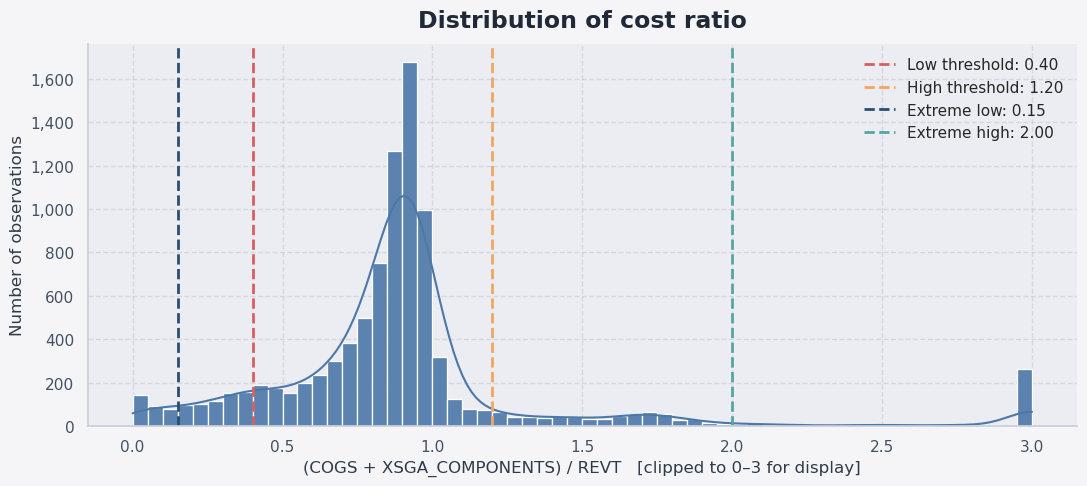

In [21]:
plot_data = panel.loc[panel["cost_ratio"].notna(), "cost_ratio"]

fig, ax = plot_ratio_distribution(
    plot_data,
    low_threshold=LOW_THRESHOLD,
    high_threshold=HIGH_THRESHOLD,
    extreme_low=EXTREME_LOW_THRESHOLD,
    extreme_high=EXTREME_HIGH_THRESHOLD,
)

register_figure(fig, "cost_ratio_distribution")
plt.show()
plt.close(fig)


In [22]:
def extract_exchange(ticker):
    if pd.isna(ticker):
        return "Unknown"
    ticker = str(ticker)
    if "." in ticker:
        return ticker.split(".")[-1]
    return "Unknown"

panel["Exchange"] = panel["Ticker"].apply(extract_exchange)

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


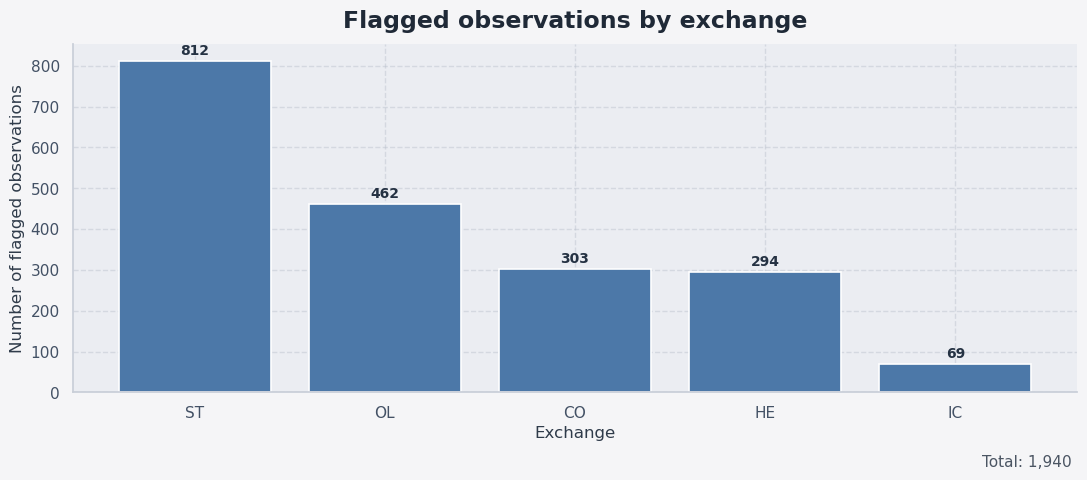

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


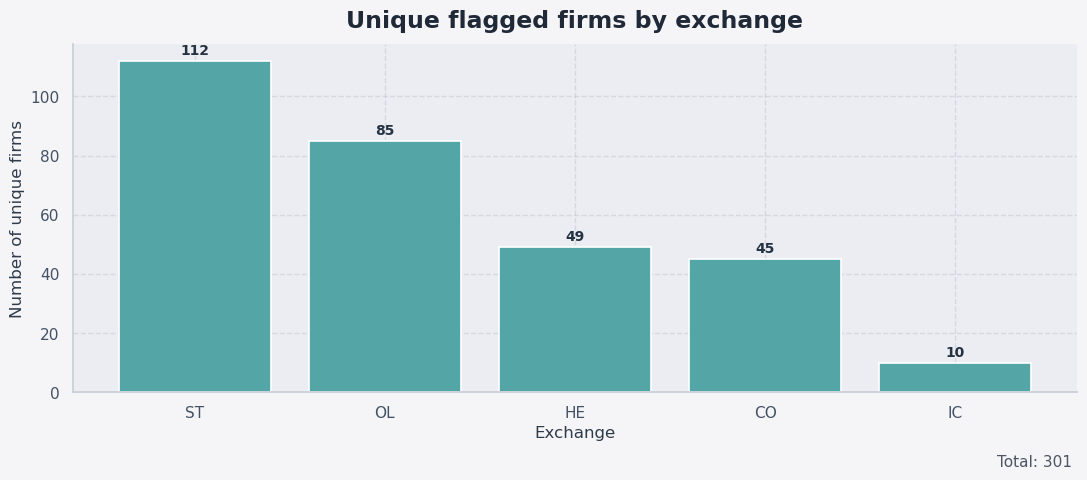

,Exchange,flagged_observations,unique_flagged_firms
0,ST,812,112
1,OL,462,85
2,CO,303,45
3,HE,294,49
4,IC,69,10


In [23]:
flagged = panel.loc[panel["flag_any"]].copy()

exchange_obs = (
    flagged.groupby("Exchange")
    .size()
    .sort_values(ascending=False)
    .head(TOP_N_EXCHANGES)
)

exchange_firms = (
    flagged.groupby("Exchange")["Ticker"]
    .nunique()
    .sort_values(ascending=False)
    .head(TOP_N_EXCHANGES)
)

fig, ax = plot_annotated_bar(
    exchange_obs,
    title="Flagged observations by exchange",
    xlabel="Exchange",
    ylabel="Number of flagged observations",
    color=PALETTE["blue"],
    top_n=TOP_N_EXCHANGES,
    rotation=0,
)
register_figure(fig, "flagged_observations_by_exchange")

fig, ax = plot_annotated_bar(
    exchange_firms,
    title="Unique flagged firms by exchange",
    xlabel="Exchange",
    ylabel="Number of unique firms",
    color=PALETTE["teal"],
    top_n=TOP_N_EXCHANGES,
    rotation=0,
)
register_figure(fig, "unique_flagged_firms_by_exchange")

exchange_counts = (
    pd.DataFrame({
        "Exchange": exchange_obs.index,
        "flagged_observations": exchange_obs.values,
        "unique_flagged_firms": exchange_firms.reindex(exchange_obs.index).fillna(0).astype(int).values,
    })
)

save_plot_data("exchange_counts", exchange_counts)
display(exchange_counts)


/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


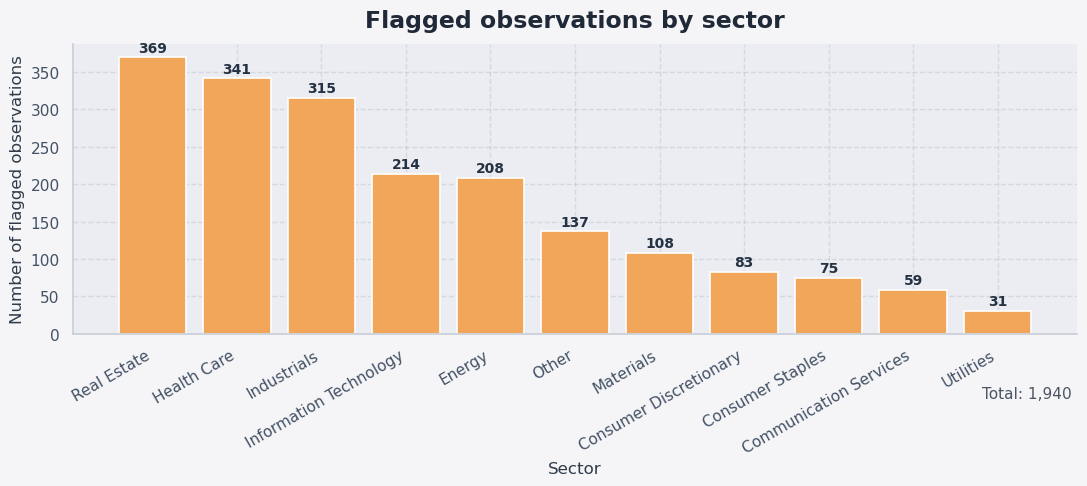

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


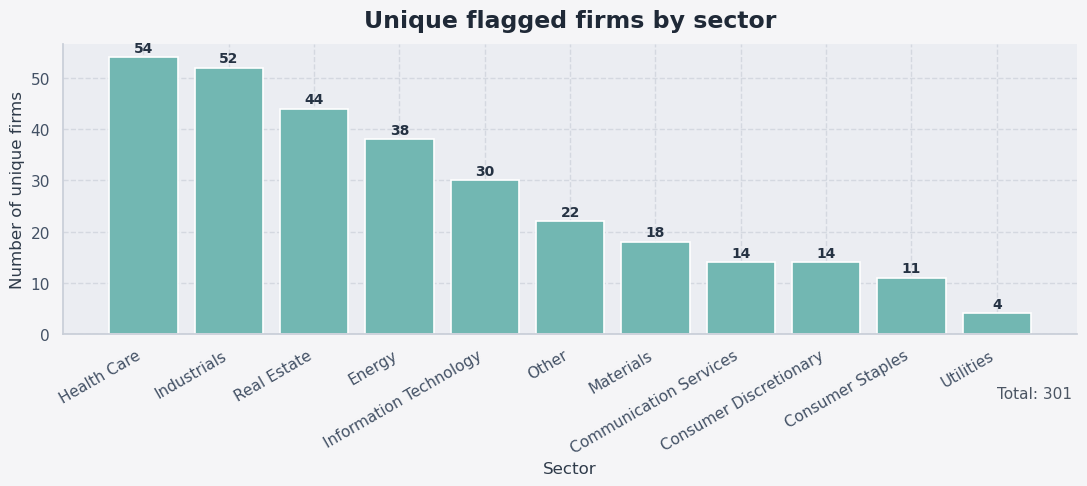

,Sector,flagged_observations,unique_flagged_firms
0,Real Estate,369,44
1,Health Care,341,54
2,Industrials,315,52
3,Information Technology,214,30
4,Energy,208,38
5,Other,137,22
6,Materials,108,18
7,Consumer Discretionary,83,14
8,Consumer Staples,75,11
9,Communication Services,59,14


In [24]:
if "Sector" in flagged.columns:
    sector_obs = (
        flagged.groupby("Sector")
        .size()
        .sort_values(ascending=False)
        .head(TOP_N_SECTORS)
    )

    sector_firms = (
        flagged.groupby("Sector")["Ticker"]
        .nunique()
        .sort_values(ascending=False)
        .head(TOP_N_SECTORS)
    )

    fig, ax = plot_annotated_bar(
        sector_obs,
        title="Flagged observations by sector",
        xlabel="Sector",
        ylabel="Number of flagged observations",
        color=PALETTE["orange"],
        top_n=TOP_N_SECTORS,
        rotation=30,
    )
    register_figure(fig, "flagged_observations_by_sector")

    fig, ax = plot_annotated_bar(
        sector_firms,
        title="Unique flagged firms by sector",
        xlabel="Sector",
        ylabel="Number of unique firms",
        color=PALETTE["green"],
        top_n=TOP_N_SECTORS,
        rotation=30,
    )
    register_figure(fig, "unique_flagged_firms_by_sector")

    sector_counts = (
        pd.DataFrame({
            "Sector": sector_obs.index,
            "flagged_observations": sector_obs.values,
            "unique_flagged_firms": sector_firms.reindex(sector_obs.index).fillna(0).astype(int).values,
        })
    )

    save_plot_data("sector_counts", sector_counts)
    display(sector_counts)
else:
    print("Column 'Sector' not found.")


In [25]:
summary = panel[["cost_ratio"]].describe()
print(summary)

print("\nThresholds used:")
print(f"LOW_THRESHOLD          = {LOW_THRESHOLD}")
print(f"HIGH_THRESHOLD         = {HIGH_THRESHOLD}")
print(f"EXTREME_LOW_THRESHOLD  = {EXTREME_LOW_THRESHOLD}")
print(f"EXTREME_HIGH_THRESHOLD = {EXTREME_HIGH_THRESHOLD}")
print(f"MIN_REVENUE            = {MIN_REVENUE}")

n_total = len(panel)
n_valid = panel["REVT_valid"].sum()
n_flagged = panel["flag_any"].sum()
n_low = panel["flag_low"].sum()
n_high = panel["flag_high"].sum()

n_unique_firms_total = panel["Ticker"].nunique()
n_unique_firms_valid = panel.loc[panel["REVT_valid"], "Ticker"].nunique()
n_unique_firms_flagged = panel.loc[panel["flag_any"], "Ticker"].nunique()

print("\nCounts:")
print(f"Total rows             : {n_total:,}")
print(f"Valid ratio rows       : {n_valid:,}")
print(f"Flagged rows           : {n_flagged:,}")
print(f"  Low flagged          : {n_low:,}")
print(f"  High flagged         : {n_high:,}")
print(f"Unique firms total     : {n_unique_firms_total:,}")
print(f"Unique firms valid     : {n_unique_firms_valid:,}")
print(f"Unique firms flagged   : {n_unique_firms_flagged:,}")


        cost_ratio
count  9363.000000
mean      1.233700
std       3.751420
min       0.000000
25%       0.723061
50%       0.887158
75%       0.960717
max     107.758662

Thresholds used:
LOW_THRESHOLD          = 0.4
HIGH_THRESHOLD         = 1.2
EXTREME_LOW_THRESHOLD  = 0.15
EXTREME_HIGH_THRESHOLD = 2.0
MIN_REVENUE            = 1.0

Counts:
Total rows             : 9,774
Valid ratio rows       : 9,363
Flagged rows           : 1,940
  Low flagged          : 936
  High flagged         : 1,004
Unique firms total     : 635
Unique firms valid     : 627
Unique firms flagged   : 301


In [26]:
flag_summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Valid ratio rows",
        "Flagged rows",
        "Low flagged rows",
        "High flagged rows",
        "Unique firms total",
        "Unique firms valid",
        "Unique firms flagged",
    ],
    "value": [
        len(panel),
        panel["REVT_valid"].sum(),
        panel["flag_any"].sum(),
        panel["flag_low"].sum(),
        panel["flag_high"].sum(),
        panel["Ticker"].nunique(),
        panel.loc[panel["REVT_valid"], "Ticker"].nunique(),
        panel.loc[panel["flag_any"], "Ticker"].nunique(),
    ],
})

save_plot_data("flag_summary", flag_summary)
display_summary_table(flag_summary)


metric,value
Total rows,"9,774"
Valid ratio rows,"9,363"
Flagged rows,"1,940"
Low flagged rows,936
High flagged rows,"1,004"
Unique firms total,635
Unique firms valid,627
Unique firms flagged,301


/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


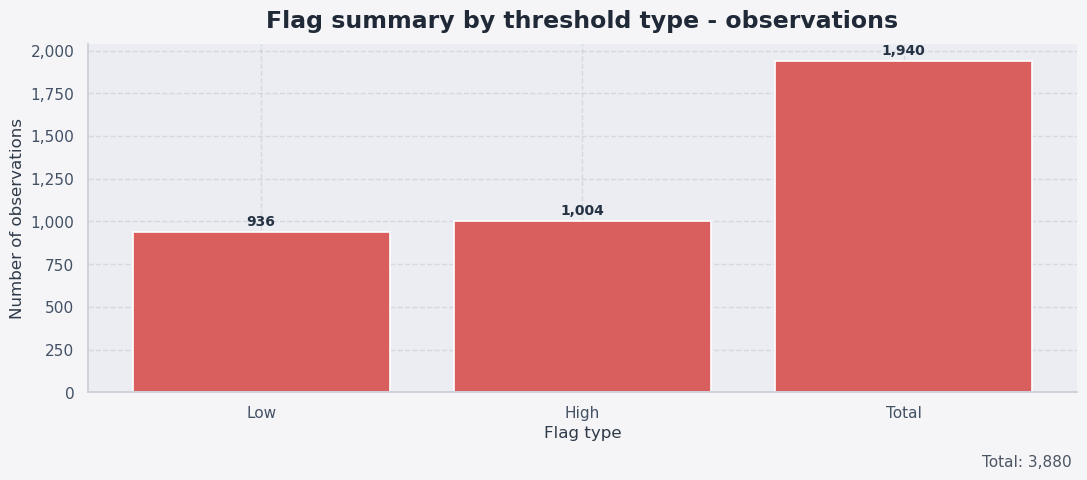

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


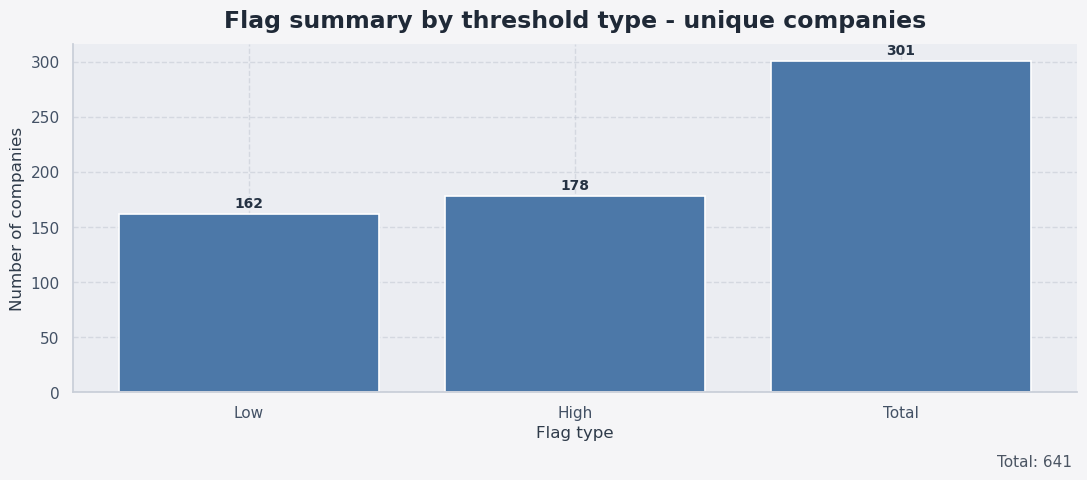

PosixPath('plot_exports/flag_type_counts.parquet')

In [27]:
flag_type_counts = pd.DataFrame({
    "flag_type": ["Low", "High", "Total"],
    "observations": [
        int(panel["flag_low"].sum()),
        int(panel["flag_high"].sum()),
        int(panel["flag_any"].sum()),
    ],
    "unique_companies": [
        panel.loc[panel["flag_low"], "Ticker"].nunique(),
        panel.loc[panel["flag_high"], "Ticker"].nunique(),
        panel.loc[panel["flag_any"], "Ticker"].nunique(),
    ]
}).set_index("flag_type")

flag_type_counts


fig_obs, ax_obs = plot_annotated_bar(
    flag_type_counts["observations"],
    title="Flag summary by threshold type - observations",
    xlabel="Flag type",
    ylabel="Number of observations",
    color=PALETTE["red"],
    rotation=0,
)
register_figure(fig_obs, "flag_summary_observations")
plt.show()

fig_comp, ax_comp = plot_annotated_bar(
    flag_type_counts["unique_companies"],
    title="Flag summary by threshold type - unique companies",
    xlabel="Flag type",
    ylabel="Number of companies",
    color=PALETTE["blue"],
    rotation=0,
)
register_figure(fig_comp, "flag_summary_unique_companies")
plt.show()

save_plot_data(
    "flag_type_counts",
    flag_type_counts.reset_index()
)

In [28]:
def classify_flag(row):
    if row["flag_low"] and row["flag_high"]:
        return "Both"
    if row["flag_low"]:
        return "Low"
    if row["flag_high"]:
        return "High"
    return "Not flagged"

flagged = panel.loc[panel["flag_any"]].copy()
flagged["flag_type"] = flagged.apply(classify_flag, axis=1)

show_cols = [
    "Ticker",
    "CompanyName",
    "Year",
    "Exchange",
    "Industry",
    "Sector",
    "REVT",
    "COGS",
    "XSGA_COMPONENTS",
    "TOTAL_COST_PROXY",
    "cost_ratio",
    "flag_type",
]

show_cols = [c for c in show_cols if c in flagged.columns]

flagged_table = (
    flagged[show_cols]
    .sort_values(["flag_type", "cost_ratio"], ascending=[True, True])
    .reset_index(drop=True)
)

save_plot_data("flagged_table", flagged_table)
flagged_table.head()


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
0,NRC.OL,NRC Group ASA,2011,OL,Construction & Engineering,Industrials,288.63,100.15,246.28,346.43,1.200256,High
1,DOV1V.HE,Dovre Group Oyj,2024,HE,Professional & Commercial Services,Industrials,1154.26,1217.77,167.71,1385.48,1.200319,High
2,EMGS.OL,Electromagnetic Geoservices ASA,2008,OL,Oil & Gas Related Equipment and Services,Energy,655.97,398.16,389.78,787.94,1.201183,High
3,SOBIV.ST,Swedish Orphan Biovitrum AB (publ),2011,ST,Pharmaceuticals,Health Care,1650.38,808.65,1174.78,1983.43,1.201802,High
4,DIGIGR.HE,Digitalist Group Oyj,2018,HE,Software & IT Services,Information Technology,237.51,21.83,263.67,285.50,1.202055,High


In [29]:
display(
    HTML(
        flagged_table.to_html(index=False, max_rows=200, max_cols=None)
    )
)


Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
NRC.OL,NRC Group ASA,2011,OL,Construction & Engineering,Industrials,288.63,100.15,246.28,346.43,1.200256,High
DOV1V.HE,Dovre Group Oyj,2024,HE,Professional & Commercial Services,Industrials,1154.26,1217.77,167.71,1385.48,1.200319,High
EMGS.OL,Electromagnetic Geoservices ASA,2008,OL,Oil & Gas Related Equipment and Services,Energy,655.97,398.16,389.78,787.94,1.201183,High
SOBIV.ST,Swedish Orphan Biovitrum AB (publ),2011,ST,Pharmaceuticals,Health Care,1650.38,808.65,1174.78,1983.43,1.201802,High
DIGIGR.HE,Digitalist Group Oyj,2018,HE,Software & IT Services,Information Technology,237.51,21.83,263.67,285.50,1.202055,High
ROVS.CO,Rovsing A/S,2012,CO,Software & IT Services,Information Technology,18.79,7.38,15.22,22.60,1.202767,High
DIGIGR.HE,Digitalist Group Oyj,2017,HE,Software & IT Services,Information Technology,186.60,22.10,202.48,224.58,1.203537,High
BIOGb.ST,Biogaia AB,2008,ST,Pharmaceuticals,Health Care,124.18,41.26,108.33,149.59,1.204622,High
AKH.OL,Aker Horizons ASA,2024,OL,Electric Utilities & IPPs,Utilities,2537.00,1228.00,1829.00,3057.00,1.204966,High
EMGS.OL,Electromagnetic Geoservices ASA,2016,OL,Oil & Gas Related Equipment and Services,Energy,373.86,152.61,297.90,450.51,1.205023,High


In [30]:
display(flagged_table)


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
0,NRC.OL,NRC Group ASA,2011,OL,Construction & Engineering,Industrials,288.63,100.15,246.28,346.43,1.200256,High
1,DOV1V.HE,Dovre Group Oyj,2024,HE,Professional & Commercial Services,Industrials,1154.26,1217.77,167.71,1385.48,1.200319,High
2,EMGS.OL,Electromagnetic Geoservices ASA,2008,OL,Oil & Gas Related Equipment and Services,Energy,655.97,398.16,389.78,787.94,1.201183,High
3,SOBIV.ST,Swedish Orphan Biovitrum AB (publ),2011,ST,Pharmaceuticals,Health Care,1650.38,808.65,1174.78,1983.43,1.201802,High
4,DIGIGR.HE,Digitalist Group Oyj,2018,HE,Software & IT Services,Information Technology,237.51,21.83,263.67,285.50,1.202055,High
...,...,...,...,...,...,...,...,...,...,...,...,...
1935,STWK.ST,Stockwik Forvaltning AB,2012,ST,Professional & Commercial Services,Industrials,129.27,0.00,51.61,51.61,0.399242,Low
1936,TEL.OL,Telenor ASA,2005,OL,Telecommunications Services,Communication Services,66566.00,16432.00,10145.00,26577.00,0.399258,Low
1937,NAVA.OL,Navamedic ASA,2012,OL,Pharmaceuticals,Health Care,88.68,0.00,35.41,35.41,0.399301,Low
1938,WALLb.ST,Wallenstam AB,2014,ST,Real Estate Operations,Real Estate,1438.50,403.26,171.77,575.03,0.399743,Low


In [31]:
low_flagged = flagged_table.loc[flagged_table["flag_type"] == "Low"].reset_index(drop=True)
high_flagged = flagged_table.loc[flagged_table["flag_type"] == "High"].reset_index(drop=True)

print(f"Low flagged rows : {len(low_flagged):,}")
print(f"High flagged rows: {len(high_flagged):,}")

display(low_flagged.head(50))
display(high_flagged.head(50))


Low flagged rows : 936
High flagged rows: 1,004


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
0,ENSG.CO,Ennogie Solar Group A/S,2005,CO,Construction & Engineering,Industrials,195.29,0.0,0.0,0.0,0.0,Low
1,ENSG.CO,Ennogie Solar Group A/S,2009,CO,Construction & Engineering,Industrials,177.39,0.0,0.0,0.0,0.0,Low
2,ENSG.CO,Ennogie Solar Group A/S,2010,CO,Construction & Engineering,Industrials,36.32,0.0,0.0,0.0,0.0,Low
3,ENSG.CO,Ennogie Solar Group A/S,2011,CO,Construction & Engineering,Industrials,88.94,0.0,0.0,0.0,0.0,Low
4,ENSG.CO,Ennogie Solar Group A/S,2012,CO,Construction & Engineering,Industrials,40.23,0.0,0.0,0.0,0.0,Low
5,HKFOODS.HE,HKFoods Oyj,2005,HE,Food & Tobacco,Consumer Staples,7074.68,0.0,0.0,0.0,0.0,Low
6,HKFOODS.HE,HKFoods Oyj,2006,HE,Food & Tobacco,Consumer Staples,7515.43,0.0,0.0,0.0,0.0,Low
7,HKFOODS.HE,HKFoods Oyj,2007,HE,Food & Tobacco,Consumer Staples,16881.32,0.0,0.0,0.0,0.0,Low
8,HKFOODS.HE,HKFoods Oyj,2008,HE,Food & Tobacco,Consumer Staples,18897.24,0.0,0.0,0.0,0.0,Low
9,INVEST.HE,Investors House Oyj,2005,HE,Real Estate Operations,Real Estate,6.38,0.0,0.0,0.0,0.0,Low


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
0,NRC.OL,NRC Group ASA,2011,OL,Construction & Engineering,Industrials,288.63,100.15,246.28,346.43,1.200256,High
1,DOV1V.HE,Dovre Group Oyj,2024,HE,Professional & Commercial Services,Industrials,1154.26,1217.77,167.71,1385.48,1.200319,High
2,EMGS.OL,Electromagnetic Geoservices ASA,2008,OL,Oil & Gas Related Equipment and Services,Energy,655.97,398.16,389.78,787.94,1.201183,High
3,SOBIV.ST,Swedish Orphan Biovitrum AB (publ),2011,ST,Pharmaceuticals,Health Care,1650.38,808.65,1174.78,1983.43,1.201802,High
4,DIGIGR.HE,Digitalist Group Oyj,2018,HE,Software & IT Services,Information Technology,237.51,21.83,263.67,285.50,1.202055,High
5,ROVS.CO,Rovsing A/S,2012,CO,Software & IT Services,Information Technology,18.79,7.38,15.22,22.60,1.202767,High
6,DIGIGR.HE,Digitalist Group Oyj,2017,HE,Software & IT Services,Information Technology,186.60,22.10,202.48,224.58,1.203537,High
7,BIOGb.ST,Biogaia AB,2008,ST,Pharmaceuticals,Health Care,124.18,41.26,108.33,149.59,1.204622,High
8,AKH.OL,Aker Horizons ASA,2024,OL,Electric Utilities & IPPs,Utilities,2537.00,1228.00,1829.00,3057.00,1.204966,High
9,EMGS.OL,Electromagnetic Geoservices ASA,2016,OL,Oil & Gas Related Equipment and Services,Energy,373.86,152.61,297.90,450.51,1.205023,High


In [32]:
# Run this cell after all plots above have been created.
# Change PLOT_VERSION in the first cell before re-running if you want a new export folder.
save_all_registered_plots()


Saved 7 plots to: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plots/baseline
 - cost_ratio_distribution.png
 - flagged_observations_by_exchange.png
 - unique_flagged_firms_by_exchange.png
 - flagged_observations_by_sector.png
 - unique_flagged_firms_by_sector.png
 - flag_summary_observations.png
 - flag_summary_unique_companies.png
